In [1]:
import spacy
from nltk import tokenize
import pandas as pd
import pickle
from rapidfuzz import fuzz
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

# 0) Import data

In [2]:
# Import metadata
df = pd.read_csv("../data/document_data_clean_filtered.csv")

In [25]:
#Create_backup:
shutil.copy("../data/document_data_clean_filtered.csv", "../data/document_data_clean_filtered_auto_backup.csv")
# Save df:
df.to_csv("../data/document_data_clean_filtered.csv", index=False)

# 0.5) Create contexts:

In [ ]:
for i, doc in df.iterrows():
    with open(f"../data/corpus_txt/{doc["ark"]}.txt", "r", encoding='utf-8') as f:
        paragraphs = f.readlines()

    pertinent_context = []
    for j, paragraph in enumerate(paragraphs):
        if fuzz.ratio("eucalyptus", paragraph.lower()) > 75 or "eucalyp" in paragraph.lower() or "encalypt" in paragraph.lower() or "eucalipt" in paragraph.lower():
            pertinent_context = pertinent_context + paragraphs[j-1:j+1]

    pertinent_context = list(set(pertinent_context))                

    with open(f"../data/corpus_eucalyptus_only/{doc["ark"]}.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(pertinent_context))

    if i % 100 == 0:
        print(f"{i} documents done")

100 documents done
600 documents done
1700 documents done
1100 documents done
44800 documents done
300 documents done
1000 documents done
3000 documents done
5000 documents done
9400 documents done
2700 documents done
100 documents done
100 documents done
1000 documents done
2900 documents done
4400 documents done
600 documents done
100 documents done
1100 documents done
2000 documents done
600 documents done
3200 documents done
5600 documents done
7600 documents done
100 documents done
600 documents done
800 documents done
200 documents done
700 documents done
900 documents done
5400 documents done
1000 documents done
100 documents done
400 documents done
100 documents done
100 documents done
3400 documents done
300 documents done
300 documents done
200 documents done
2500 documents done
6000 documents done
600 documents done
7200 documents done
200 documents done
100 documents done
3200 documents done
5400 documents done
4500 documents done
22500 documents done
400 documents done
590

In [ ]:
# Verify contexts: - A voir si 0 paragraphes pour généraliste + officielles puis tout pour  
#                       les autres?
df.sample(50, random_state=50)
["x", "x", "tout doc", "x", "x", "0 / tout doc", "x+3", "x+3", "paragraphe trop long", "x", "x", "tout doc", "tout doc", "pas pertinent", "tout doc", "tout doc", "x", ]

,ark,title_clean,date_clean,author_name_clean,author_type_clean,author_birth_clean,author_death_clean,publisher_name_clean,publisher_place_clean,type_clean,...,title,author,date,publisher,ocr_quality,topics,metatopics,occurences,occurences_ratio,publisher_place_country
9182,bpt6k5128548t,Le Sémaphore de l'Ouest,1916.0,"Syndicat commercial et industriel (Oran, dépar...",person,NaN,NaN,NaN,Oran,presse généraliste,...,"Le Sémaphore de l'Ouest : journal commercial, ...","Syndicat commercial et industriel (Oran, dépar...",1916-10-14,[s.n.] (Oran),82.0,[21],['Institutions / Transport'],1,0.036751,Afrique du Nord
8071,bpt6k619736d,Le Petit journal,1912.0,Parti social français,entity,NaN,NaN,NaN,Paris,presse généraliste,...,Le Petit journal,Parti social français. Auteur du texte,1912-05-30,[s.n.] (Paris),75.0,"[28, 125]","['Autres', 'Erreurs']",2,0.003892,Paris / Île de France
3253,bpt6k6289772k,Bulletin trimestriel de la Société d'agricultu...,1897.0,Société d'agriculture de Joigny,entity,NaN,NaN,Typ. Zanote,Joigny,presse spécialisée,...,Bulletin trimestriel de la Société d'agricultu...,Société d'agriculture de Joigny. Auteur du texte,1897-01-01,Typ. Zanote (Joigny),99.0,[111],['Faune et Flore'],1,0.002145,France Métropolitaine
13216,bpt6k710630j,L'Univers,1901.0,NaN,NaN,NaN,NaN,L'Univers,Paris,presse généraliste,...,L'Univers,NaN,1901-02-04,L'Univers (Paris),95.0,[40],['Géographie'],1,0.004232,Paris / Île de France
7664,bpt6k97832077,Histoire moderne et contemporaine,1878.0,"Riquier, Alfred Louis",person,1819.0,1887.0,Librairie Ch. Delagrave,Paris,monographie,...,Histoire moderne et contemporaine / par M. A. ...,"Riquier, Alfred Louis (1819-1887). Auteur du t...",1878,Librairie Ch. Delagrave (Paris),99.0,[0],['Géographie'],1,0.000780,Paris / Île de France
5982,bpt6k6501205g,Journal officiel de Madagascar et dépendances,1905.0,Madagascar,entity,NaN,NaN,Imprimerie nationale,Tananarive,presse officielle,...,Journal officiel de Madagascar et dépendances,Madagascar. Auteur du texte,1905-08-05,Imprimerie nationale (Tananarive),100.0,"[131, 80]","['Erreurs', 'Institutions / Transport']",2,0.006339,Madagascar
9888,bpt6k7051077n,Bulletin de la Société d'horticulture d'Orléans,1880.0,Société d'horticulture d'Orléans et du Loiret,entity,NaN,NaN,NaN,Orléans,presse spécialisée,...,Bulletin de la Société d'horticulture d'Orléans,Société d'horticulture d'Orléans et du Loiret....,1880,[s.n.] (Orléans),89.0,[8],['Faune et Flore'],1,0.000470,Autres
7437,bpt6k7156372d,Journal général de l'Algérie et de la Tunisie,1910.0,Syndicat des entrepreneurs de travaux publics ...,entity,NaN,NaN,NaN,Alger,presse généraliste,...,Journal général de l'Algérie et de la Tunisie ...,Syndicat des entrepreneurs de travaux publics ...,1910-01-23,[s.n.?] (Alger),86.0,[107],['Médecine/Médicaments'],1,0.005843,Afrique du Nord
5696,bpt6k6068386w,Journal général de l'Algérie et de la Tunisie,1904.0,Syndicat des entrepreneurs de travaux publics ...,entity,NaN,NaN,NaN,Alger,presse généraliste,...,Journal général de l'Algérie et de la Tunisie ...,Syndicat des entrepreneurs de travaux publics ...,1904-10-27,[s.n.?] (Alger),87.0,"[83, 71]","['Institutions / Transport', 'Institutions / T...",4,0.021902,Afrique du Nord
639,bpt6k7050422r,Manuel de gynécologie,1886.0,"Hart, David Berry",person,NaN,NaN,A. Delahaye et E. Lecrosnier,Paris,monographie,...,"Manuel de gynécologie / par D. Berry Hart,... ...","Hart, David Berry. Auteur du texte",1886,A. Delahaye et E. Lecrosnier (Paris),89.0,"[42, 12]","['Médecine/Médicaments', 'Médecine/Médicaments']",2,0.000925,Paris / Île de France


# 1) Occurrences

In [ ]:
def get_occurrences(ark, target="eucalyptus", ratio=75, path="../data/corpus_txt/"):
    with open(f"{path}{ark}.txt", "r", encoding='utf-8') as f:
        text = f.read().split()

    if type(target) is not list:
        occurrences = 0
        for word in text:
            if target == "eucalyptus":
                if fuzz.ratio("eucalyptus", word.lower()) > ratio or "eucalypt" in word.lower() or "encalypt" in word.lower() or "eucalipt" in word.lower():
                    occurrences += 1
            else:
                if fuzz.ratio(target, word.lower()) > ratio or target in word.lower():
                    occurrences += 1
        
        return occurrences

    else:
        occurrences_list = [0 for x in target]
        for word in text:
            for i, word_target in enumerate(target):
                if word_target == "eucalyptus":
                    if fuzz.ratio("eucalyptus", word.lower()) > ratio or "eucalypt" in word.lower() or "encalypt" in word.lower() or "eucalipt" in word.lower():
                        occurrences_list[i] += 1
                else:
                    if fuzz.ratio(word_target, word.lower()) > ratio or word_target in word.lower():
                        occurrences_list[i] += 1
    
        return occurrences_list

## 1.1) Occurrences Eucalyptus

In [ ]:
docs_occurrences = []
for doc in df["ark"].to_list():
    docs_occurrences.append(get_occurrences(doc))

df["occurences"] = docs_occurrences

In [ ]:
docs_eucalyptus_ratio = []
for i, ark in enumerate(df["ark"].to_list()):
    with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
        text = f.read().split()

    docs_eucalyptus_ratio.append(df.iloc[i]["occurences"] / len(text) * 100)

df["occurences_ratio"] = docs_eucalyptus_ratio

In [21]:
df["occurences_ratio"].describe()

count    17190.000000
mean         0.010299
std          0.038541
min          0.000026
25%          0.001671
50%          0.004397
75%          0.009936
max          2.762240
Name: occurences_ratio, dtype: float64

In [26]:
df.sort_values(by="occurences_ratio", ascending=False)[["occurences_ratio", "occurences", "title_clean", "date_clean", "author_name_clean", "type_clean"]].head(15)

,occurences_ratio,occurences,title_clean,date_clean,author_name_clean,type_clean
3516,2.762240,400,L'eucalyptus et ses dérivés,1898.0,"Combes, Paul",monographie
6237,1.547591,266,L'eucalyptus et ses applications industrielles,1877.0,"Martin, Félix (ingénieur des Ponts et chaussées)",monographie
2078,1.166614,110,Observations cliniques sur l'eucalyptus globul...,1872.0,"Brunel, Adolphe",monographie
829,1.099592,35,Note sur le miel eucalypté naturel sécrété par...,1887.0,"Thomas-Caraman, Charles",monographie
2077,1.086840,101,Observations cliniques sur l'eucalyptus globul...,1872.0,"Brunel, Adolphe",monographie
1572,0.860957,267,"L'""Eucalyptus globulus"", son importance en agr...",1870.0,"Gimbert, Dr (de Cannes)",monographie
1727,0.811893,71,"L'""eucalyptus globulus""",1870.0,"Gimbert, Dr (de Cannes)",monographie
3891,0.798359,218,Assainissement des régions chaudes insalubres,1875.0,"Carlotti, Antoine-Louis-Régulus",monographie
1044,0.762232,506,"Les eucalyptus, aire géographique de leur indi...",1888.0,"Sahut, Félix",monographie
3924,0.655269,289,L'eucalyptus,1875.0,"Raveret-Wattel, Casimir",monographie


In [27]:
df.sort_values(by="occurences", ascending=False)[["occurences_ratio", "occurences", "title_clean", "date_clean", "author_name_clean", "type_clean"]].head(15)

,occurences_ratio,occurences,title_clean,date_clean,author_name_clean,type_clean
1044,0.762232,506,"Les eucalyptus, aire géographique de leur indi...",1888.0,"Sahut, Félix",monographie
2068,0.127590,450,Bulletin de la Société d'acclimatation,1872.0,Société nationale de protection de la nature (...,presse spécialisée
3516,2.762240,400,L'eucalyptus et ses dérivés,1898.0,"Combes, Paul",monographie
2707,0.085454,320,Bulletin de la Société d'acclimatation,1873.0,Société nationale de protection de la nature (...,presse spécialisée
4761,0.083271,291,Bulletin de la Société d'acclimatation,1876.0,Société nationale de protection de la nature (...,presse spécialisée
3924,0.655269,289,L'eucalyptus,1875.0,"Raveret-Wattel, Casimir",monographie
12057,0.089422,275,La Médecine moderne,1894.0,NaN,presse spécialisée
17114,0.198267,267,Annales des sciences naturelles.... Botanique,1883.0,NaN,presse spécialisée
1572,0.860957,267,"L'""Eucalyptus globulus"", son importance en agr...",1870.0,"Gimbert, Dr (de Cannes)",monographie
6237,1.547591,266,L'eucalyptus et ses applications industrielles,1877.0,"Martin, Félix (ingénieur des Ponts et chaussées)",monographie


In [30]:
df.groupby(by="type_clean")["occurences_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
type_clean,,,,,,,,
annuaire,199.0,0.001365,0.002553,0.000047,0.000178,0.000527,0.001581,0.020210
monographie,4295.0,0.010796,0.067757,0.000026,0.001076,0.002388,0.006223,2.762240
presse généraliste,7997.0,0.010587,0.022651,0.000064,0.002964,0.005720,0.010731,0.522759
presse officielle,1352.0,0.010235,0.017622,0.000102,0.002293,0.004823,0.010887,0.223010
presse spécialisée,3347.0,0.009530,0.019529,0.000040,0.000995,0.003590,0.009982,0.448430


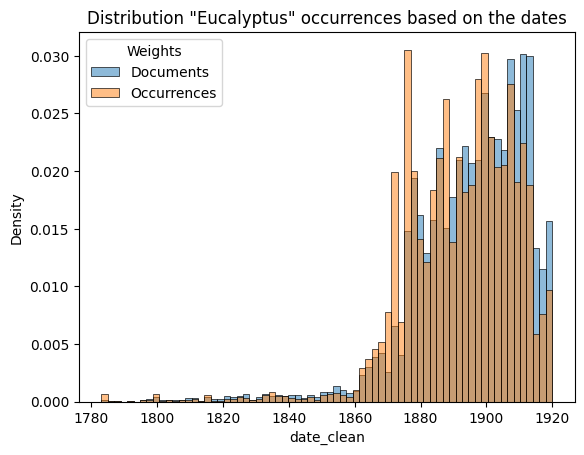

In [6]:
sns.histplot(df, x="date_clean", bins=70, stat="density", label='Documents', alpha=0.5)
sns.histplot(df, x="date_clean", weights="occurences", bins=70, stat="density", label='Occurrences', alpha=0.5)
plt.legend(title= "Weights", loc= "upper left")
plt.title('Distribution "Eucalyptus" occurrences based on the dates')
plt.show()

## 1.2) Specific place occurrences

In [14]:
#Palestine
palestine_occurrences = []
for doc in df["ark"].to_list():
    palestine_occurrences.append(get_occurrences(doc, target="palestine", ratio=85))

df["palestine"] = palestine_occurrences

In [12]:
df[df["type_clean"] != "annuaire"].sort_values(by="palestine", ascending=False)[["palestine", "occurences", "title_clean", "date_clean", "author_name_clean", "type_clean"]].head(15)

,palestine,occurences,title_clean,date_clean,author_name_clean,type_clean
13133,12,28,L'Écho sioniste,1900.0,NaN,presse généraliste
10305,9,5,Février-mai 1880. Herborisations au Levant,1882.0,"Barbey, William",monographie
953,4,2,"Dictionnaire géographique, administratif, post...",1869.0,"Joanne, Adolphe",monographie
12967,4,1,Revue de théologie et des questions religieuses,1900.0,NaN,presse généraliste
15601,4,2,Guide Rosenwald,1913.0,NaN,presse généraliste
12901,3,1,L'Écho sioniste,1899.0,NaN,presse généraliste
16192,3,1,L'Univers israélite,1915.0,NaN,presse généraliste
16316,3,1,Guide Rosenwald,1917.0,NaN,presse généraliste
6786,2,1,Bulletin trimestriel,1908.0,"Société d'agriculture, d'horticulture et d'acc...",presse spécialisée
47,2,8,Revue trimestrielle de la Société d'archéologi...,1884.0,"Société d'archéologie, de littérature, science...",presse spécialisée


# 1.3) Mediterranean places - Using Spacy

In [4]:
# Load csv from each country:
france_df = pd.read_csv("../data/other/communes-france-2025.csv")
algeria_df = pd.read_csv("../data/other/algeria_cities.csv")
morroco_df = pd.read_excel("../data/other/codes-postaux-localites-2018.xlsx")
tunisia_df = pd.read_csv("../data/other/Municipalites_Liste.csv")


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20380\3304699064.py:2: DtypeWarning: Columns (0: code_insee, 1: dep_code, 2: canton_code, 3: epci_code, 4: code_insee_centre_zone_emploi, 5: code_unite_urbaine) have mixed types. Specify dtype option on import or set low_memory=False.
  france_df = pd.read_csv("../data/other/communes-france-2025.csv")


In [5]:
places = {}

for _, row in france_df.iterrows():
    places[row["nom_sans_pronom"].lower()] = "France"

for _, row in algeria_df.iterrows():
    places[row["commune_name"].lower()] = "Algerie"
    places[row["daira_name"].lower()] = "Algerie"
    places[row["wilaya_name"].lower()] = "Algerie"

for _, row in morroco_df.iterrows():
    places[row["REGION_POSTALE"].lower()] = "Maroc"
    places[row["PROVINCE"].lower()] = "Maroc"
    places[row["LOCALITE"].lower()] = "Maroc"

for _, row in tunisia_df.iterrows():
    places[row["Libelle_gouvernorat_Fr"].lower()] = "Tunisie"
    places[row["Libelle_commune_fr"].lower()] = "Tunisie"

places["france"] = "France"
places["algerie"] = "Algerie"
places["maroc"] = "Maroc"
places["tunisie"] = "Tunisie"

In [6]:
# Load the pre-trained model
nlp = spacy.load("fr_core_news_lg")

c:\Users\ASUS\Programmation\lhst-the-ecology-of-eucalyptus\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
place_occurrences = {
    "France": [],
    "Algerie": [],
    "Maroc": [],
    "Tunisie": []
}

ratio = 0.75

for i, ark in enumerate(df["ark"].to_list()):
    with open(f"../data/corpus_eucalyptus_only/{ark}.txt", "r", encoding='utf-8') as f:
        text = f.read()

    list_of_texts = []
    list_of_nlp_docs = []

    if len(text) > 1000000:
        list_of_texts += textwrap.wrap(text, 100000)
    else:
        list_of_texts.append(text)

    for text in list_of_texts:
        list_of_nlp_docs.append(nlp(text))

    doc_occurrences = {
        "France": 0,
        "Algerie": 0,
        "Maroc": 0,
        "Tunisie": 0
    }

    for nlp_doc in list_of_nlp_docs:
        for word in [ent for ent in nlp_doc.ents if ent.label_ == "LOC"]:
            for place in places.keys():
                if fuzz.ratio(place, str(word).lower()) > ratio or place in str(word).lower():
                    doc_occurrences[places[place]] += 1
                    continue
    
    place_occurrences["France"].append(doc_occurrences["France"])
    place_occurrences["Algerie"].append(doc_occurrences["Algerie"])
    place_occurrences["Maroc"].append(doc_occurrences["Maroc"])
    place_occurrences["Tunisie"].append(doc_occurrences["Tunisie"])

    if i % 100 == 0:
        print(f"{i} documents done")

df["France"] = doc_occurrences["France"]
df["Algerie"] = doc_occurrences["Algerie"]
df["Maroc"] = doc_occurrences["Maroc"]
df["Tunisie"] = doc_occurrences["Tunisie"]


0 documents done
100 documents done
200 documents done
300 documents done
400 documents done
500 documents done
600 documents done
700 documents done
800 documents done
900 documents done


KeyboardInterrupt: 

In [ ]:
# Save df:
df.to_csv("../data/document_data_clean_filtered_test_with_occurrences_places.csv", index=False)

# 2) Apply spacy to all texts

In [21]:
docs_ner = []

for ark in df["ark"].to_list():
    with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
            text = f.read()
    docs_ner.append(nlp(text))

#Save docs_ner
with open("docs_ner.pkl", "wb") as fp:
    pickle.dump(docs_ner, fp)

ValueError: [E088] Text of length 3676236 exceeds maximum of 1000000. The parser and NER models require roughly 1GB of temporary memory per 100,000 characters in the input. This means long texts may cause memory allocation errors. If you're not using the parser or NER, it's probably safe to increase the `nlp.max_length` limit. The limit is in number of characters, so you can check whether your inputs are too long by checking `len(text)`.